# Classic ML

In [13]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import PredefinedSplit

from mortality_prediction.utils import DATA_DIR

## 1 — Load prepared data


In [2]:
df_a = pd.read_parquet(os.path.join(DATA_DIR, "set_a_vector_imputed.parquet"))
df_b = pd.read_parquet(os.path.join(DATA_DIR, "set_b_vector_imputed.parquet"))
df_c = pd.read_parquet(os.path.join(DATA_DIR, "set_c_vector_imputed.parquet"))

print(f"Vector shape — A: {df_a.shape}, B: {df_b.shape}, C: {df_c.shape}")
df_a.head(3)

Vector shape — A: (4000, 258), B: (4000, 258), C: (4000, 258)


,PatientID,Albumin_min,Albumin_max,Albumin_last,Albumin_mean,Albumin_slope,Albumin_auc,Albumin_crossings,ALP_min,ALP_max,...,WBC_last,WBC_mean,WBC_slope,WBC_auc,WBC_crossings,age,height_cm,weight_kg,gender,in_hospital_death
0,132539,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,-0.312018,-0.151598,-0.014260,-3.410958,1.0,-0.514851,0.000000,0.000000,0.0,0.0
1,132540,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.328042,-0.037835,0.022983,5.532629,1.0,0.356436,0.335526,0.037736,1.0,0.0
2,132541,-0.666667,-0.222222,-0.666667,-0.444444,-0.034858,-5.666667,1.0,0.241481,0.540465,...,-1.051109,-1.554884,0.019776,-59.684528,1.0,-0.910891,0.000000,-0.857143,0.0,0.0


## 4 — Logistic Regression on Set A — feature contributions

In [3]:
feature_cols = [c for c in df_a.columns if c not in ("PatientID", "in_hospital_death")]

X_a = df_a[feature_cols].to_numpy()
y_a = df_a["in_hospital_death"].to_numpy()

clf = LogisticRegression(max_iter=1000, solver="lbfgs")
clf.fit(X_a, y_a)

print(f"Training accuracy (set A): {clf.score(X_a, y_a):.3f}")
print(f"Positive class rate:       {y_a.mean():.3f}")

Training accuracy (set A): 0.890
Positive class rate:       0.139


/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
coef_df = (
    pd.DataFrame({"feature": feature_cols, "coefficient": clf.coef_[0]})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
    .drop(columns="abs_coef")
    .reset_index(drop=True)
)

print(coef_df.to_string(index=False))

              feature  coefficient
             GCS_last     2.828113
              pH_mean     1.439296
           PaO2_slope     1.037013
               pH_min    -0.958999
        TroponinT_max     0.831732
             BUN_last     0.821088
              GCS_max    -0.742569
              HR_mean    -0.724894
        DiasABP_slope     0.715350
       Creatinine_min     0.632162
            AST_slope     0.597995
        Bilirubin_max    -0.591640
        Bilirubin_min     0.582176
             ALT_last    -0.575603
      Creatinine_last    -0.549731
              Na_last     0.517195
                  age     0.504014
             ALP_last    -0.475806
             ALP_mean     0.475232
        Lactate_slope     0.451513
       TroponinT_last    -0.451366
        RespRate_mean     0.441656
              ALP_max     0.420724
             Mg_slope     0.387758
        MechVent_last    -0.376074
         MechVent_min    -0.376074
         MechVent_max    -0.376074
        MechVent_mea

## 5 — Selected aggregation per TS parameter

In [5]:
SELECTED_AGG = {
    # last — current status
    "GCS": "last",
    "BUN": "last",
    "Creatinine": "last",
    "ALT": "last",
    "Na": "last",
    "Albumin": "last",
    "Glucose": "last",
    "NIMAP": "last",
    "MechVent": "last",
    "FiO2": "last",
    # mean — sustained vitals / labs
    "pH": "mean",
    "NIDiasABP": "mean",
    "HCO3": "mean",
    "ALP": "mean",
    "NISysABP": "mean",
    "Lactate": "mean",
    "MAP": "mean",
    "Urine": "mean",
    "Platelets": "mean",
    "Mg": "mean",
    "HR": "mean",
    "PaO2": "mean",
    "DiasABP": "mean",
    "SaO2": "mean",
    "K": "mean",
    "SysABP": "mean",
    # max — peaks of failure
    "TroponinT": "max",
    "Bilirubin": "max",
    "WBC": "max",
    "AST": "max",
    "PaCO2": "max",
    "Cholesterol": "max",
    # min — lows of failure
    "RespRate": "min",
    "HCT": "min",
    "Temp": "min",
    "TroponinI": "min",
}

STATIC_COLS = ["age", "height_cm", "weight_kg", "gender"]

selected_cols = (
    ["PatientID"]
    + [f"{p}_{agg}" for p, agg in SELECTED_AGG.items()]
    + STATIC_COLS
    + ["in_hospital_death"]
)

sel_a = df_a[selected_cols]
sel_b = df_b[selected_cols]
sel_c = df_c[selected_cols]

print(f"Selected vector shape — A: {sel_a.shape}, B: {sel_b.shape}, C: {sel_c.shape}")
sel_a.head(3)

Selected vector shape — A: (4000, 42), B: (4000, 42), C: (4000, 42)


,PatientID,GCS_last,BUN_last,Creatinine_last,ALT_last,Na_last,Albumin_last,Glucose_last,NIMAP_last,MechVent_last,...,Cholesterol_max,RespRate_min,HCT_min,Temp_min,TroponinI_min,age,height_cm,weight_kg,gender,in_hospital_death
0,132539,0.000000,-1.307822,-0.662249,0.000000,-0.500000,0.000000,-0.365161,0.2165,0.0,...,0.0,-1.0,0.000000,-2.0,0.0,-0.514851,0.000000,0.000000,0.0,0.0
1,132540,0.000000,-0.008289,0.064703,0.000000,-0.666667,0.000000,0.289078,-0.3335,1.0,...,0.0,0.0,-0.903226,-2.6,0.0,0.356436,0.335526,0.037736,1.0,0.0
2,132541,0.833333,-2.486843,-1.307395,0.060812,-0.166667,-0.666667,0.232121,1.4000,1.0,...,0.0,0.0,-0.580645,-0.4,0.0,-0.910891,0.000000,-0.857143,0.0,0.0


## 6 — Prepare train / val / test splits

In [6]:
feat_cols = [c for c in sel_a.columns if c not in ("PatientID", "in_hospital_death")]

X_train = sel_a[feat_cols].to_numpy()
y_train = sel_a["in_hospital_death"].to_numpy()

X_val = sel_b[feat_cols].to_numpy()
y_val = sel_b["in_hospital_death"].to_numpy()

X_test = sel_c[feat_cols].to_numpy()
y_test = sel_c["in_hospital_death"].to_numpy()

print(f"Train  — {X_train.shape}  |  positives: {y_train.mean():.3f}")
print(f"Val    — {X_val.shape}    |  positives: {y_val.mean():.3f}")
print(f"Test   — {X_test.shape}   |  positives: {y_test.mean():.3f}")

# PredefinedSplit: -1 = train fold, 0 = val fold
# GridSearchCV uses this to treat set B as the single held-out split.
X_trainval = np.concatenate([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
split_index = np.concatenate(
    [
        np.full(len(X_train), -1),  # train
        np.zeros(len(X_val), dtype=int),  # val
    ]
)
ps = PredefinedSplit(split_index)

Train  — (4000, 40)  |  positives: 0.139
Val    — (4000, 40)    |  positives: 0.142
Test   — (4000, 40)   |  positives: 0.146


## 7 — Logistic Regression grid search (validate on set B)

In [7]:
lr_grid = GridSearchCV(
    LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        solver="lbfgs",
    ),
    param_grid={"C": [0.01, 0.1, 1.0, 10.0]},
    scoring="roc_auc",
    cv=ps,
    refit=False,
    n_jobs=-1,
)
lr_grid.fit(X_trainval, y_trainval)

lr_results = pd.DataFrame(lr_grid.cv_results_)[["param_C", "mean_test_score"]]
lr_results.columns = ["C", "val_AuROC"]
print(lr_results.to_string(index=False))

best_lr_C = lr_grid.best_params_["C"]
print(f"\nBest LR: C={best_lr_C}  val AuROC={lr_grid.best_score_:.4f}")

best_lr = LogisticRegression(
    penalty="l2",
    C=best_lr_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs",
)
best_lr.fit(X_train, y_train)

    C  val_AuROC
 0.01   0.838331
 0.10   0.847372
 1.00   0.845432
10.00   0.845027

Best LR: C=0.1  val AuROC=0.8474


/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

## 8 — Random Forest grid search (validate on set B)

In [8]:
rf_grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "max_depth": [5, 10, 15],
        "n_estimators": [100, 200],
    },
    scoring="roc_auc",
    cv=ps,
    refit=False,
    n_jobs=1,  # outer loop sequential; inner RF already uses n_jobs=-1
)
rf_grid.fit(X_trainval, y_trainval)

rf_results = (
    pd.DataFrame(rf_grid.cv_results_)[
        ["param_max_depth", "param_n_estimators", "mean_test_score"]
    ]
    .rename(
        columns={
            "param_max_depth": "max_depth",
            "param_n_estimators": "n_estimators",
            "mean_test_score": "val_AuROC",
        }
    )
    .sort_values("val_AuROC", ascending=False)
)
print(rf_results.to_string(index=False))

best_rf_params = rf_grid.best_params_
print(f"\nBest RF: {best_rf_params}  val AuROC={rf_grid.best_score_:.4f}")

best_rf = RandomForestClassifier(
    **best_rf_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
best_rf.fit(X_train, y_train)

 max_depth  n_estimators  val_AuROC
        10           200   0.848418
        15           200   0.847007
        10           100   0.844833
         5           200   0.844346
         5           100   0.843012
        15           100   0.842510

Best RF: {'max_depth': 10, 'n_estimators': 200}  val AuROC=0.8484


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## 9 — Test set C evaluation (AuROC & AuPRC)

Model                             AuROC    AuPRC
----------------------------------------------------
LR (C=0.1)                       0.8469   0.4973
RF (depth=10, n=200)             0.8484   0.4732


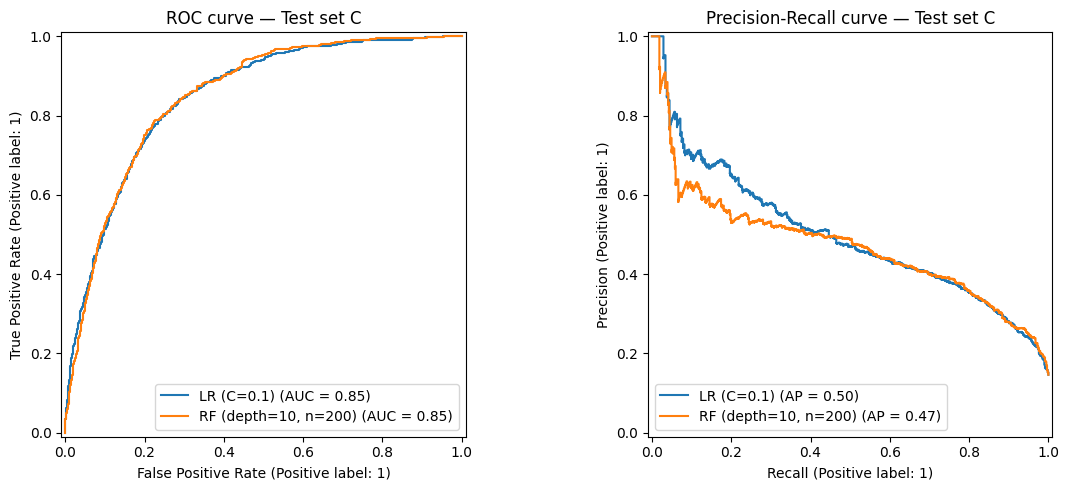

In [9]:
models = {
    f"LR (C={best_lr_C})": best_lr,
    f"RF (depth={best_rf_params['max_depth']}, n={best_rf_params['n_estimators']})": best_rf,
}

print("=" * 52)
print(f"{'Model':<30}  {'AuROC':>7}  {'AuPRC':>7}")
print("-" * 52)
for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    auroc = roc_auc_score(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    print(f"{name:<30}  {auroc:>7.4f}  {auprc:>7.4f}")
print("=" * 52)

# --- curves ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, model in models.items():
    probs = model.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, probs, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=name, ax=axes[1])

axes[0].set_title("ROC curve — Test set C")
axes[1].set_title("Precision-Recall curve — Test set C")
plt.tight_layout()
plt.show()

## 10 — Feature selection pipeline

### Step 1 — Drop zero-variance features

In [14]:
all_feat_cols = [c for c in df_a.columns if c not in ("PatientID", "in_hospital_death")]
X_all_train = df_a[all_feat_cols].to_numpy(dtype=float)
X_all_val = df_b[all_feat_cols].to_numpy(dtype=float)
X_all_test = df_c[all_feat_cols].to_numpy(dtype=float)

vt = VarianceThreshold(threshold=0.0)
vt.fit(X_all_train)
mask_vt = vt.get_support()
cols_vt = [c for c, keep in zip(all_feat_cols, mask_vt, strict=True) if keep]

dropped_vt = [c for c, keep in zip(all_feat_cols, mask_vt, strict=True) if not keep]
print(f"Before : {len(all_feat_cols)} features")
print(f"After  : {len(cols_vt)} features  ({len(dropped_vt)} dropped)\n")
print("Dropped (zero-variance):")
for c in dropped_vt:
    print(f"  {c}")

Before : 256 features
After  : 254 features  (2 dropped)

Dropped (zero-variance):
  MechVent_slope
  MechVent_crossings


### Step 2 — Spearman correlation filter (keep top 150)

In [15]:
from scipy.stats import spearmanr

y_tr = df_a["in_hospital_death"].to_numpy(dtype=float)
X_vt_train = X_all_train[:, mask_vt]

abs_corr = []
for i in range(X_vt_train.shape[1]):
    r, _ = spearmanr(X_vt_train[:, i], y_tr)
    abs_corr.append(abs(r) if not np.isnan(r) else 0.0)

spearman_s = pd.Series(abs_corr, index=cols_vt).sort_values(ascending=False)

TOP_SPEARMAN = 150
cols_spearman = spearman_s.head(TOP_SPEARMAN).index.tolist()

print(f"After Spearman filter (top {TOP_SPEARMAN}): {len(cols_spearman)} features\n")
print(f"Top {TOP_SPEARMAN} by |Spearman |:")
print(spearman_s.head(150).to_string())

After Spearman filter (top 150): 150 features

Top 150 by |Spearman |:
GCS_last                0.310967
GCS_min                 0.246929
BUN_last                0.235042
BUN_min                 0.228932
BUN_mean                0.228421
BUN_auc                 0.228011
GCS_auc                 0.223234
BUN_max                 0.220357
GCS_mean                0.216782
Urine_mean              0.205759
Urine_auc               0.198389
GCS_slope               0.189792
Urine_max               0.187975
Urine_last              0.167719
HCO3_last               0.155326
MechVent_auc            0.154490
Creatinine_auc          0.151094
Creatinine_mean         0.150411
Creatinine_max          0.149987
Creatinine_min          0.145469
Creatinine_last         0.144894
age                     0.137435
HCO3_auc                0.135790
Glucose_max             0.134087
HCO3_mean               0.133640
HCO3_min                0.129680
PaCO2_min               0.120321
Lactate_crossings       0.117618
PaCO2

### Step 3 — Random Forest importance filter

In [16]:
spearman_idx = [all_feat_cols.index(c) for c in cols_spearman]
X_sp_train = X_all_train[:, spearman_idx]

rf_sel = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_sel.fit(X_sp_train, y_tr)

importance_s = pd.Series(rf_sel.feature_importances_, index=cols_spearman).sort_values(
    ascending=False
)

print("RF feature importances (all surviving features):")
print(importance_s.to_string())

RF feature importances (all surviving features):
GCS_last                0.046083
GCS_mean                0.036075
BUN_mean                0.027214
GCS_auc                 0.026062
GCS_slope               0.025996
BUN_last                0.024292
BUN_auc                 0.023174
GCS_min                 0.021945
BUN_min                 0.021409
Urine_mean              0.019101
Urine_auc               0.018858
BUN_max                 0.014744
MechVent_auc            0.013360
Urine_max               0.012977
age                     0.010804
weight_kg               0.010564
Temp_mean               0.009762
Temp_auc                0.009515
PaCO2_auc               0.009105
Urine_last              0.009083
WBC_last                0.008880
PaCO2_mean              0.008628
Creatinine_mean         0.008391
Na_slope                0.008260
Creatinine_min          0.008151
HCO3_mean               0.008086
Glucose_auc             0.008063
HR_max                  0.008023
Creatinine_auc          0.0

### Step 4 — Keep features with importance > 0.004

In [17]:
IMPORTANCE_THRESHOLD = 0.004
final_features = importance_s[importance_s > IMPORTANCE_THRESHOLD].index.tolist()

print(f"Features with importance > {IMPORTANCE_THRESHOLD}: {len(final_features)}\n")
print(f"{'Feature':<40}  {'Importance':>10}")
print("-" * 54)
for feat in final_features:
    print(f"{feat:<40}  {importance_s[feat]:>10.4f}")

final_idx = [all_feat_cols.index(c) for c in final_features]
X_final_train = X_all_train[:, final_idx]
X_final_val = X_all_val[:, final_idx]
X_final_test = X_all_test[:, final_idx]

print(
    f"\nFinal shapes — train: {X_final_train.shape}, val: {X_final_val.shape}, test: {X_final_test.shape}"
)

Features with importance > 0.004: 103

Feature                                   Importance
------------------------------------------------------
GCS_last                                      0.0461
GCS_mean                                      0.0361
BUN_mean                                      0.0272
GCS_auc                                       0.0261
GCS_slope                                     0.0260
BUN_last                                      0.0243
BUN_auc                                       0.0232
GCS_min                                       0.0219
BUN_min                                       0.0214
Urine_mean                                    0.0191
Urine_auc                                     0.0189
BUN_max                                       0.0147
MechVent_auc                                  0.0134
Urine_max                                     0.0130
age                                           0.0108
weight_kg                                     0.0106
Temp_

## 11 — Train best models on final features & evaluate on test set C

/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/

Best LR C=0.1  val AuROC=0.8557
Best RF {'max_depth': 15, 'n_estimators': 200}  val AuROC=0.8497


/workspaces/intensive_care_time_series_modeling_for_mortality_predictions/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



Model                                         AuROC    AuPRC
--------------------------------------------------------------
LR-final (C=0.1, k=103)                      0.8473   0.5033
RF-final ({'max_depth': 15, 'n_estimators': 200}, k=103)   0.8478   0.4732


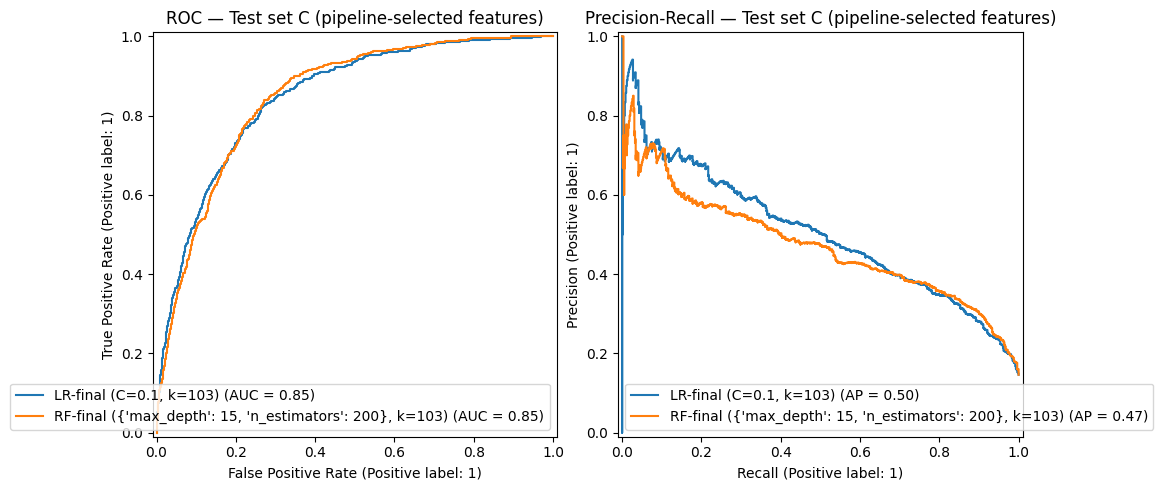

In [18]:
# Grid search on final features, using the same PredefinedSplit as before
X_final_trainval = np.concatenate([X_final_train, X_final_val])
ps_final = PredefinedSplit(split_index)  # split_index built in section 6

lr_final_grid = GridSearchCV(
    LogisticRegression(
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        solver="lbfgs",
    ),
    param_grid={"C": [0.01, 0.1, 1.0, 10.0]},
    scoring="roc_auc",
    cv=ps_final,
    refit=False,
    n_jobs=-1,
)
lr_final_grid.fit(X_final_trainval, y_trainval)
best_lr_final_C = lr_final_grid.best_params_["C"]
print(f"Best LR C={best_lr_final_C}  val AuROC={lr_final_grid.best_score_:.4f}")

rf_final_grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid={"max_depth": [5, 10, 15], "n_estimators": [100, 200]},
    scoring="roc_auc",
    cv=ps_final,
    refit=False,
    n_jobs=1,
)
rf_final_grid.fit(X_final_trainval, y_trainval)
best_rf_final_params = rf_final_grid.best_params_
print(f"Best RF {best_rf_final_params}  val AuROC={rf_final_grid.best_score_:.4f}")

# Refit winners on train-only
lr_final = LogisticRegression(
    penalty="l2",
    C=best_lr_final_C,
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs",
)
lr_final.fit(X_final_train, y_train)

rf_final = RandomForestClassifier(
    **best_rf_final_params,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_final.fit(X_final_train, y_train)

# Evaluate on test set C
final_models = {
    f"LR-final (C={best_lr_final_C}, k={len(final_features)})": lr_final,
    f"RF-final ({best_rf_final_params}, k={len(final_features)})": rf_final,
}

print("\n" + "=" * 62)
print(f"{'Model':<42}  {'AuROC':>7}  {'AuPRC':>7}")
print("-" * 62)
for name, model in final_models.items():
    probs = model.predict_proba(X_final_test)[:, 1]
    auroc = roc_auc_score(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    print(f"{name:<42}  {auroc:>7.4f}  {auprc:>7.4f}")
print("=" * 62)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, model in final_models.items():
    probs = model.predict_proba(X_final_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, probs, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=name, ax=axes[1])
axes[0].set_title("ROC — Test set C (pipeline-selected features)")
axes[1].set_title("Precision-Recall — Test set C (pipeline-selected features)")
plt.tight_layout()
plt.show()